8 features reduced to 2
variance kept: 31.0 %


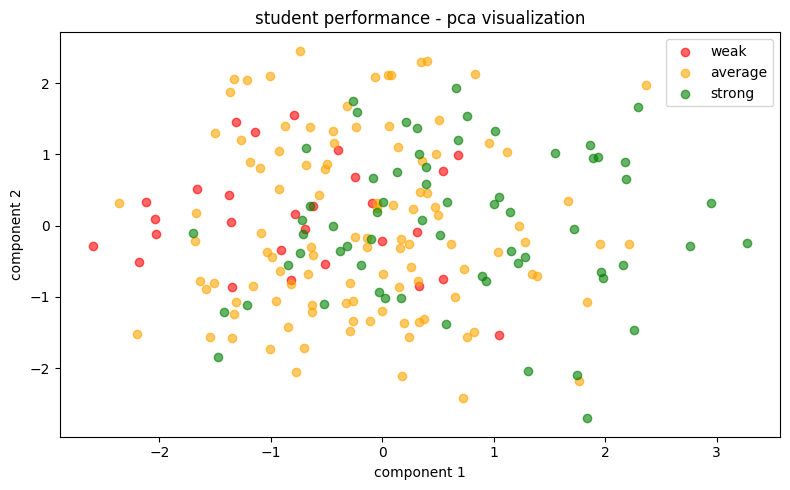

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

data = {
    "maths":      np.random.randint(40, 100, n),
    "english":    np.random.randint(40, 100, n),
    "science":    np.random.randint(40, 100, n),
    "hindi":      np.random.randint(40, 100, n),
    "computer":   np.random.randint(40, 100, n),
    "attendance": np.random.randint(50, 100, n),
    "assignments":np.random.randint(0, 10, n),
    "projects":   np.random.randint(0, 5, n)
}

df = pd.DataFrame(data)

df["performance"] = pd.cut(
    df[["maths","english","science"]].mean(axis=1),
    bins=[0, 60, 75, 100],
    labels=["weak", "average", "strong"]
)

x = df.drop("performance", axis=1)
y = df["performance"]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

print("8 features reduced to 2")
print("variance kept:",
      round(sum(pca.explained_variance_ratio_)*100, 1), "%")

colors = {"weak": "red", "average": "orange", "strong": "green"}
plt.figure(figsize=(8, 5))
for label in ["weak", "average", "strong"]:
    mask = y == label
    plt.scatter(x_pca[mask, 0], x_pca[mask, 1],
                c=colors[label], label=label, alpha=0.6)

plt.title("student performance - pca visualization")
plt.xlabel("component 1")
plt.ylabel("component 2")
plt.legend()
plt.tight_layout()
plt.show()